In [1]:
# ICS 471 - Project Proposal
# Loading EuroSAT and getting the stuff I need for the proposal (samples, class counts, plots)

In [2]:
# installing the datasets library first
!pip install datasets -q

from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# loading eurosat from hugging face
dataset = load_dataset("Honaker/eurosat_dataset")
print(dataset)

README.md:   0%|          | 0.00/2.71k [00:00<?, ?B/s]

data/train-00000-of-00010-1e013d76a660f3(…): reconstructing file:   0%|          |  0.00B / 7.34MB            

data/train-00000-of-00010-1e013d76a660f3(…): downloading bytes:           |  0.00B            

data/train-00001-of-00010-19150800d8e21d(…): reconstructing file:   0%|          |  0.00B / 5.94MB            

data/train-00001-of-00010-19150800d8e21d(…): downloading bytes:           |  0.00B            

...

data/test-00001-of-00002-279f1441c55d944(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/21600 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2700 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 21600
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
})


In [3]:
# the 10 classes, in order (0-9)
class_names = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop", "Residential",
    "River", "SeaLake"
]

train_data = dataset["train"]

In [4]:
# just checking the sizes of everything and what one sample looks like
print("Train size:", len(dataset["train"]))
print("Validation size:", len(dataset["validation"]))
print("Test size:", len(dataset["test"]))
print("Example item:", train_data[0])
print("Image size:", train_data[0]["image"].size)  # should be 64x64

Train size: 21600
Validation size: 2700
Test size: 2700
Example item: {'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=64x64 at 0x7ED7475AF620>, 'label': 0}
Image size: (64, 64)


In [5]:
# counting how many images are in each class so i can check the balance
labels = train_data["label"]
counts = Counter(labels)
print("\nClass counts (train split):")
for i, name in enumerate(class_names):
    print(f"{name}: {counts[i]}")


Class counts (train split):
AnnualCrop: 2373
Forest: 2390
HerbaceousVegetation: 2381
Highway: 2012
Industrial: 2012
Pasture: 1626
PermanentCrop: 1995
Residential: 2431
River: 1973
SeaLake: 2407


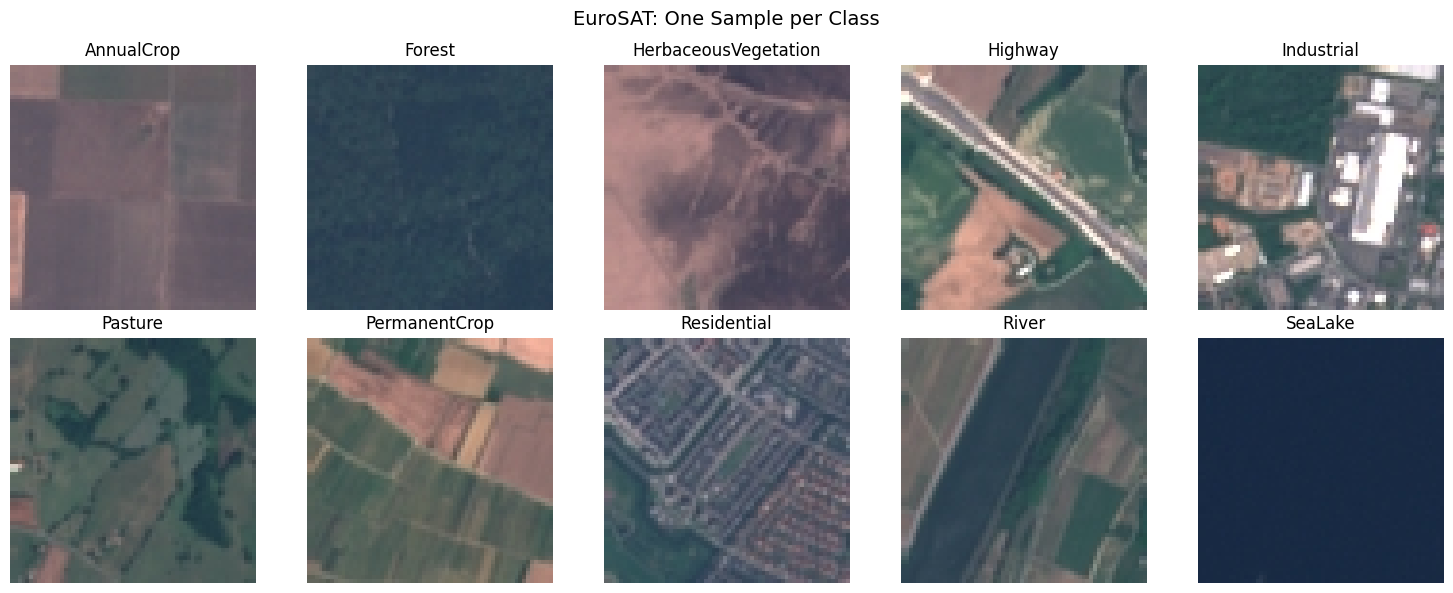

In [6]:
# grabbing one image from each class to show as samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
seen_classes = {}
for item in train_data:
    label = item["label"]
    if label not in seen_classes:
        seen_classes[label] = item["image"]
    if len(seen_classes) == 10:
        break  # got one of each, no need to keep looping

for i, ax in enumerate(axes.flat):
    ax.imshow(seen_classes[i])
    ax.set_title(class_names[i])
    ax.axis("off")

plt.suptitle("EuroSAT: One Sample per Class", fontsize=14)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

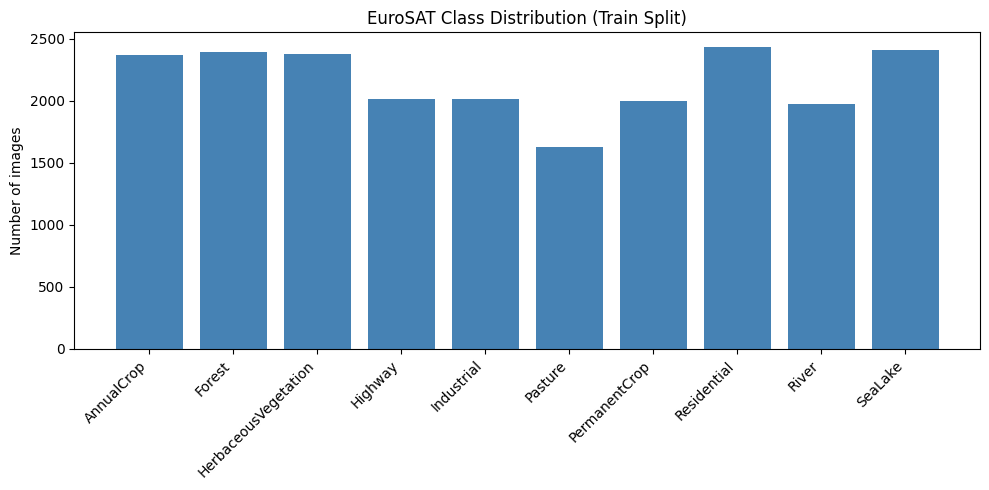

In [7]:
# bar chart for the class distribution
plt.figure(figsize=(10, 5))
counts_ordered = [counts[i] for i in range(10)]
plt.bar(class_names, counts_ordered, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("EuroSAT Class Distribution (Train Split)")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

In [8]:
# double checking all images are actually 64x64 like they're supposed to be
# (just checking a sample of 200, going through all 21600 would take forever)
sizes = set()
for item in train_data.select(range(200)):
    sizes.add(item["image"].size)
print("\nUnique image sizes found (sample of 200):", sizes)


Unique image sizes found (sample of 200): {(64, 64)}
